# Dry Bean Classification — ML Model Training

UCI Dry Bean dataset: 13,611 instances · 16 features · 7 bean classes.  
This notebook trains five classifiers, evaluates them on a held-out test set, and saves
trained artifacts () for the Streamlit app.

**Models:** Logistic Regression · Decision Tree · k-NN · Gaussian Naive Bayes · Random Forest


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

print("All libraries imported.")

All libraries imported.


## 1. Load and Explore the Dataset

In [2]:
# Works regardless of whether the notebook is opened from project root or model/ directory
cwd = os.getcwd()
ROOT = os.path.dirname(cwd) if os.path.basename(cwd) == "model" else cwd
DATA_PATH = os.path.join(ROOT, "DryBeanDataset", "Dry_Bean_Dataset.csv")
MODEL_DIR = os.path.join(ROOT, "model")

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}  ({df.shape[1]-1} features, {df.shape[0]} instances)")
print(f"Class distribution:")
print(df["Class"].value_counts().to_string())

Dataset shape: (13611, 17)  (16 features, 13611 instances)
Class distribution:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522


In [3]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
df.describe().round(3)

Missing values : 0
Duplicate rows : 68


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000,13611.000
mean,53048.285,855.283,320.142,202.271,1.583,0.751,53768.200,253.064,0.750,0.987,0.873,0.800,0.007,0.002,0.644,0.995
std,29324.096,214.290,85.694,44.970,0.247,0.092,29774.916,59.177,0.049,0.005,0.060,0.062,0.001,0.001,0.099,0.004
min,20420.000,524.736,183.601,122.513,1.025,0.219,20684.000,161.244,0.555,0.919,0.490,0.641,0.003,0.001,0.410,0.948
25%,36328.000,703.523,253.304,175.848,1.432,0.716,36714.500,215.068,0.719,0.986,0.832,0.762,0.006,0.001,0.581,0.994
50%,44652.000,794.941,296.883,192.432,1.551,0.764,45178.000,238.438,0.760,0.988,0.883,0.801,0.007,0.002,0.642,0.996
75%,61332.000,977.213,376.495,217.032,1.707,0.810,62294.000,279.446,0.787,0.990,0.917,0.834,0.007,0.002,0.696,0.998
max,254616.000,1985.370,738.860,460.198,2.430,0.911,263261.000,569.374,0.866,0.995,0.991,0.987,0.010,0.004,0.975,1.000


## 2. Class Distribution

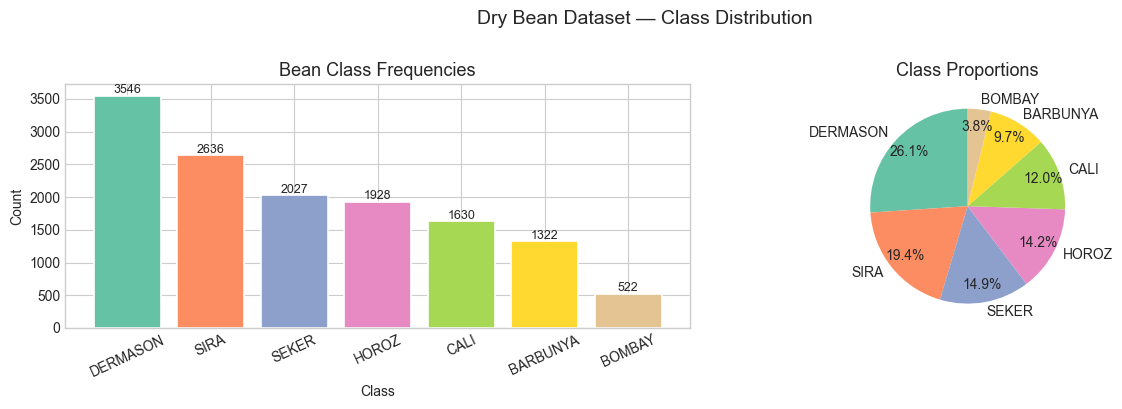

In [5]:
counts  = df["Class"].value_counts().sort_values(ascending=False)
palette = sns.color_palette("Set2", len(counts))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(counts.index, counts.values, color=palette, edgecolor="white", linewidth=1.2)
axes[0].set_title("Bean Class Frequencies", fontsize=13)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=25)
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 40, str(cnt), ha="center", fontsize=9)

axes[1].pie(counts.values, labels=counts.index, colors=palette,
            autopct="%1.1f%%", startangle=90, pctdistance=0.82)
axes[1].set_title("Class Proportions", fontsize=13)

plt.suptitle("Dry Bean Dataset — Class Distribution", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "class_distribution.png"), dpi=100, bbox_inches="tight")
plt.show()

## 3. Data Preprocessing

Steps:
1. Encode the  target column to integers using 
2. Stratified 80/20 train-test split (before scaling to prevent data leakage)
3. Fit  on **training data only**, then transform both splits
4. Save  (original scale + labels) for the Streamlit app


In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Split BEFORE scaling to avoid data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Training samples : {len(y_train)}")
print(f"Test samples     : {len(y_test)}")

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Save test set (unscaled + original class labels) for Streamlit upload
test_df = X_test_raw.copy()
test_df["Class"] = le.inverse_transform(y_test)
test_df.to_csv(os.path.join(ROOT, "test_data.csv"), index=False)
print(f"test_data.csv saved → shape {test_df.shape}")

joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler.pkl"))
joblib.dump(le,     os.path.join(MODEL_DIR, "label_encoder.pkl"))
print("scaler.pkl and label_encoder.pkl saved.")

Label encoding: {'BARBUNYA': np.int64(0), 'BOMBAY': np.int64(1), 'CALI': np.int64(2), 'DERMASON': np.int64(3), 'HOROZ': np.int64(4), 'SEKER': np.int64(5), 'SIRA': np.int64(6)}
Training samples : 10888
Test samples     : 2723
test_data.csv saved → shape (2723, 17)
scaler.pkl and label_encoder.pkl saved.


## 4. Train and Evaluate Models

Six metrics per model:

| Metric | Notes |
|--------|-------|
| Accuracy  | Overall correct predictions |
| AUC       | ROC-AUC, one-vs-rest, weighted average |
| Precision | Weighted average across 7 classes |
| Recall    | Weighted average across 7 classes |
| F1 Score  | Harmonic mean of precision and recall |
| MCC       | Matthews Correlation Coefficient — robust for unbalanced classes |


In [7]:
all_results = {}

def evaluate(label, model, X_t, y_t):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)
    metrics = {
        "Accuracy" : round(accuracy_score(y_t, y_pred), 4),
        "AUC"      : round(roc_auc_score(y_t, y_prob, multi_class="ovr", average="weighted"), 4),
        "Precision": round(precision_score(y_t, y_pred, average="weighted", zero_division=0), 4),
        "Recall"   : round(recall_score(y_t, y_pred, average="weighted", zero_division=0), 4),
        "F1 Score" : round(f1_score(y_t, y_pred, average="weighted", zero_division=0), 4),
        "MCC"      : round(matthews_corrcoef(y_t, y_pred), 4),
    }
    all_results[label] = metrics
    print(f"{chr(9472)*44}")
    print(f"  {label}")
    print(f"{chr(9472)*44}")
    for m, v in metrics.items():
        print(f"  {m:<12} {v}")
    return metrics

### 4.1 Logistic Regression

In [8]:
lr = LogisticRegression(max_iter=2000, solver="lbfgs", C=1.0, random_state=42)
lr.fit(X_train, y_train)
evaluate("Logistic Regression", lr, X_test, y_test)
joblib.dump(lr, os.path.join(MODEL_DIR, "logistic_regression.pkl"))
print("Saved → logistic_regression.pkl")

────────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────────
  Accuracy     0.9214
  AUC          0.9934
  Precision    0.9222
  Recall       0.9214
  F1 Score     0.9216
  MCC          0.905
Saved → logistic_regression.pkl


### 4.2 Decision Tree

In [9]:
dt = DecisionTreeClassifier(max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=42)
dt.fit(X_train, y_train)
evaluate("Decision Tree", dt, X_test, y_test)
joblib.dump(dt, os.path.join(MODEL_DIR, "decision_tree.pkl"))
print("Saved → decision_tree.pkl")

────────────────────────────────────────────
  Decision Tree
────────────────────────────────────────────
  Accuracy     0.8957
  AUC          0.9464
  Precision    0.8961
  Recall       0.8957
  F1 Score     0.8956
  MCC          0.8739
Saved → decision_tree.pkl


### 4.3 K-Nearest Neighbors

In [10]:
# k=7 with distance weighting tends to work well on scaled feature sets
knn = KNeighborsClassifier(n_neighbors=7, weights="distance", metric="minkowski", p=2)
knn.fit(X_train, y_train)
evaluate("KNN", knn, X_test, y_test)
joblib.dump(knn, os.path.join(MODEL_DIR, "knn.pkl"))
print("Saved → knn.pkl")

────────────────────────────────────────────
  KNN
────────────────────────────────────────────
  Accuracy     0.9166
  AUC          0.9839
  Precision    0.9173
  Recall       0.9166
  F1 Score     0.9168
  MCC          0.8992
Saved → knn.pkl


### 4.4 Gaussian Naive Bayes

In [11]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
evaluate("Gaussian Naive Bayes", gnb, X_test, y_test)
joblib.dump(gnb, os.path.join(MODEL_DIR, "naive_bayes.pkl"))
print("Saved → naive_bayes.pkl")

────────────────────────────────────────────
  Gaussian Naive Bayes
────────────────────────────────────────────
  Accuracy     0.8979
  AUC          0.9902
  Precision    0.9007
  Recall       0.8979
  F1 Score     0.8981
  MCC          0.8773
Saved → naive_bayes.pkl


### 4.5 Random Forest (Ensemble)

In [12]:
rf = RandomForestClassifier(
    n_estimators=150, max_depth=20,
    min_samples_split=4, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
evaluate("Random Forest", rf, X_test, y_test)
joblib.dump(rf, os.path.join(MODEL_DIR, "random_forest.pkl"))
print("Saved → random_forest.pkl")

────────────────────────────────────────────
  Random Forest
────────────────────────────────────────────
  Accuracy     0.9188
  AUC          0.9925
  Precision    0.919
  Recall       0.9188
  F1 Score     0.9188
  MCC          0.9018
Saved → random_forest.pkl


## 5. Results Summary

In [13]:
summary = pd.DataFrame(all_results).T
summary.index.name = "Model"

print("  MODEL COMPARISON — Dry Bean Test Set")

print(summary.to_string())
print()
best = summary["F1 Score"].idxmax()
print(f"  Best model (F1 Score): {best}")

  MODEL COMPARISON — Dry Bean Test Set
                      Accuracy     AUC  Precision  Recall  F1 Score     MCC
Model                                                                      
Logistic Regression     0.9214  0.9934     0.9222  0.9214    0.9216  0.9050
Decision Tree           0.8957  0.9464     0.8961  0.8957    0.8956  0.8739
KNN                     0.9166  0.9839     0.9173  0.9166    0.9168  0.8992
Gaussian Naive Bayes    0.8979  0.9902     0.9007  0.8979    0.8981  0.8773
Random Forest           0.9188  0.9925     0.9190  0.9188    0.9188  0.9018

  Best model (F1 Score): Logistic Regression


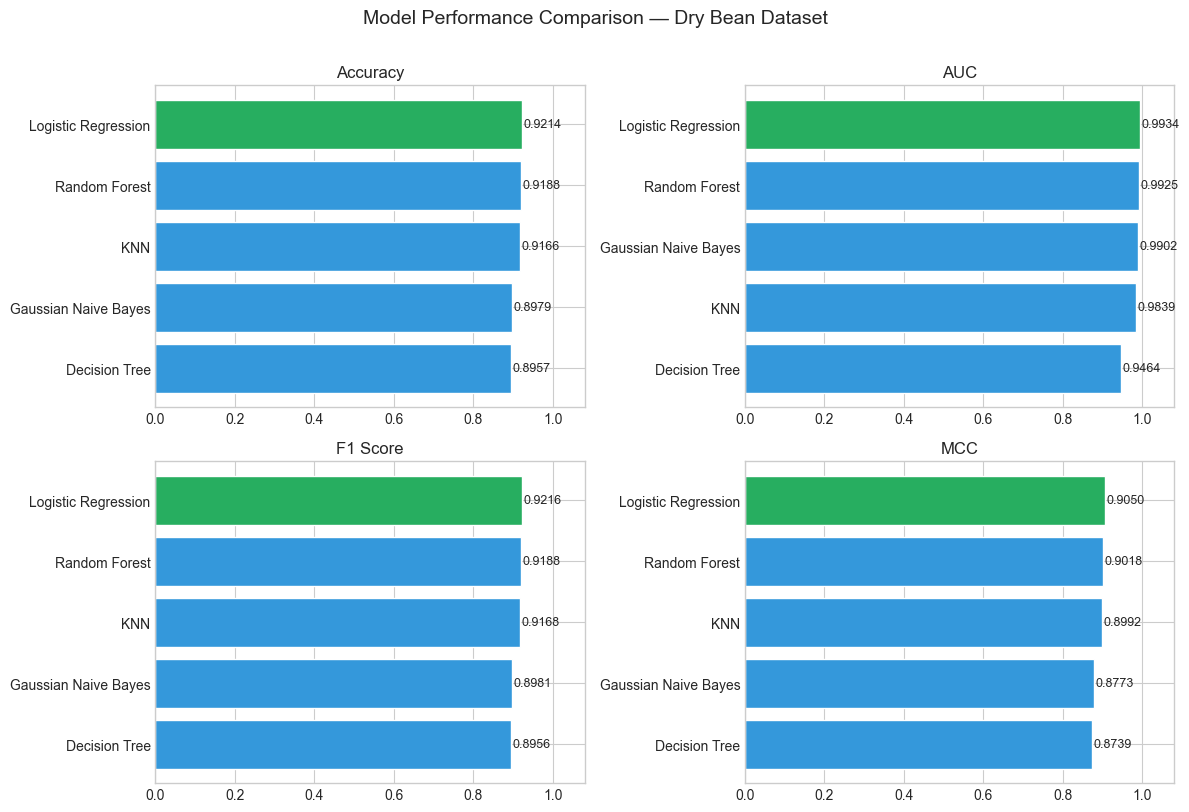

All models trained and saved successfully\!


In [14]:
metrics_to_plot = ["Accuracy", "AUC", "F1 Score", "MCC"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    vals = summary[metric].sort_values()
    bar_colors = ["#27ae60" if m == best else "#3498db" for m in vals.index]
    axes[idx].barh(vals.index, vals.values, color=bar_colors, edgecolor="white")
    axes[idx].set_title(metric, fontsize=12)
    axes[idx].set_xlim(0, 1.08)
    for j, v in enumerate(vals.values):
        axes[idx].text(v + 0.004, j, f"{v:.4f}", va="center", fontsize=9)

plt.suptitle("Model Performance Comparison — Dry Bean Dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, "model_comparison.png"), dpi=100, bbox_inches="tight")
plt.show()
print("All models trained and saved successfully!")